# 情報システム概論　第8回

## 畳み込みニューラルネットワーク
画像認識や音声認識などでよく使われる畳み込みニューラルネットワーク (convolution neural network: **CNN**) について学ぶ．

下図にCNNの例を示す．これまで見てきたニューラルネットワークは，隣接する層のすべてのニューロン間で結合があった．これを**全結合** (fully-connected) と呼び，これまでAffineレイヤとして実装していた．

CNNには新たに「Convolutionレイヤ (畳み込み層)」と「Poolingレイヤ (プーリング層)」が登場する．CNNのレイヤのつながり順は「Convolution-ReLU-(Pooling)」となる (Poolingレイヤは省略されることもある)．これは，今までの「Affine-ReLU」というつながりが「Convolution-ReLU-(Pooling)」に置き換わったと考えることができる．

さらに，出力に近い層では，これまでの「Affine-ReLU」の組み合わせが用いられている．また，最後の出力層では，これまでの「Affine-Softmax」の組み合わせが用いられる．これは一般的なCNNでよく見られる構成である．

<img alt="image00.png" width="1000" src="http://drive.google.com/uc?export=view&id=1w21z-JDippQUDF9wtIbp7iMDloVJi64Y">


## 畳み込み層

これまで見てきた全結合のニューラルネットワークでは，全結合層 (Affineレイヤ) を用いてきた．全結合層では，隣接する層のニューロンがすべて連結されている．

このような全結合層の問題は，データの形状が「無視」されてしまうことである．例えば，入力データが画像の場合，画像は通常，縦・横・チャンネル方向の3次元形状である．しかし，全結合層に入力するときは，3次元のデータを平ら (1次元のデータ) にする必要がある．実際，これまでのMNISTデータセットを使った例では，入力画像は(1, 28, 28) つまり，1チャンネル，縦28ピクセル，横28ピクセルの形状であったが，それを1列に並べた784個のデータを最初のAffineレイヤに入力していた．

一方，画像は3次元の形状であり，この形状には大切な空間的情報が含まれると考えられる．例えば，空間的に近いピクセルは似たような値であったり，RGBの各チャンネル間にはそれぞれに密接な関連性があったり，距離の離れたピクセルどうしはあまり関わりがなかったりする．このような3次元の形状の中には汲み取るべき本質的なパターンがある．しかし，全結合層では形状を無視して，すべての入力データを同等のニューロンとして扱うので，形状に関する情報を活かすことができない．

一方，畳み込み層 (Convolutionレイヤ) は，形状を維持する．画像の場合，入力データを3次元のデータとして受け取り，同じく3次元のデータとして，次の層にデータを出力する．そのため，CNNでは画像などの形状を有したデータを正しく理解できる．

なお，CNNでは畳み込み層の入出力データを**特徴マップ** (feature map) という場合がある．さらに，畳み込み層の入力データを**入力特徴マップ** (input feature map)，出力データを**出力特徴マップ** (output feature map) という．

### 畳み込み演算
畳み込み層では「畳み込み演算」をおこなう．畳み込み演算は，画像処理で言うところの「フィルタ演算」に相当する．



<img alt="image01.png" width="1000" src="http://drive.google.com/uc?export=view&id=1i3E86YClH_zuAVQFK3aBr4m0_XnXJvJU">


図に示すように，畳み込み演算は入力データに対して，フィルタを適用する (畳み込み演算を$\circledast$で表記)．この例では，入力データは縦・横方向の形状を持つデータで，フィルタも同様に，縦・横方向の次元を持つ．データとフィルタの形状を，(height, width) で表記することとして，この例では入力サイズは (4, 4)，不フィルタサイズは (3, 3)，出力サイズは (2, 2) となる．

上記のような畳み込み演算の例において，どのような計算が行われるかを示す．



<img alt="image02.png" width="1000" src="http://drive.google.com/uc?export=view&id=1Sc1h6FyEa1GE2cPXKiD0fkXWizWTl_lf">


畳み込み演算は入力データに対して，フィルタのウィンドウを一定間隔でスライドさせながら適用していく．ここでいうウィンドウとは，上図における黄色の3✕3の部分を指す．図に示すようにそれぞれの場所で，フィルタの要素と入力の対応する要素とを乗算し，その和を求める．これを**積和演算**と呼ぶこともある．そして，その結果を出力の対応する場所へ格納していく．このプロセスをすべての場所で行うことで，畳み込み演算の出力を得ることができる．

全結合のニューラルネットワークでは，重みパラメータの他にバイアスが存在していた．CNNの場合，フィルタのパラメータがこれまでの「重み」に対応する．そして，CNNの場合もバイアスが存在する．

<img alt="image03.png" width="1000" src="http://drive.google.com/uc?export=view&id=1UeiK7sucDvPtvDvlot39Fy6rMQMbIOVR">


上図に示すように，常にバイアスは一つ (1✕1) だけ存在する．その一つの値がフィルタ適用後のすべての要素に加算される．

### パディング

畳み込み層の処理を行う前に，入力データの周囲に固定のデータ (例えば0など) を埋めることがある．これを **パディング** (padding) と呼び，畳み込み演算ではよく用いられる．例えば下図の例では，(4, 4) のサイズの入力データに対して，幅1のパディングを適用している．幅1のパディングとは，周囲を幅1ピクセルの0で埋めることを言う．

<img alt="image04.png" width="1000" src="http://drive.google.com/uc?export=view&id=1rsMtczt7STotj_8NAnIeVLUB5yWdfnyi">


上図に示すように，(4, 4) のサイズの入力データはパディングによって(6, 6) の形状になる．そして，(3, 3) のサイズのフィルタをかけると，(4, 4) のサイズの出力データが生成される．上の例ではパディングを1と設定したが，パディングの値は2や3など任意の整数に設定することができる．

パディングを使う主な理由は，出力のサイズを調整するためである．例えば，(4, 4) のサイズの入力データに (3, 3) のfilterを適用する場合，出力サイズは (2, 2) になり，出力サイズは入力サイズから2要素分だけ縮小される．これは，畳み込み演算を何度も繰り返す行うようなディープなネットワークでは，問題になる．なぜなら，畳み込み演算を行うたびに空間的に縮小されるのであれば，ある時点で出力サイズが1になってしまい，それ以上畳み込み演算が適用できなくなるからである．

### ストライド
フィルタを適用する位置の間隔を **ストライド** (stride) という．これまで見てきた例はすべてストライドが1だったが，例えば，ストライドを2にすると下図のようにフィルタを適用する窓の間隔が2要素ごとになる．


<img alt="image05.png" width="1000" src="http://drive.google.com/uc?export=view&id=1EqdHaBp8Ul9YzH1TlA-arAvzjXjs88j2">


このように，ストライドを大きくすると出力サイズは小さくなる．一方，パディングを大きくすれば出力サイズは大きくなる．このような関係性を定式化してみる．

ここでは，入力サイズを (H, W)，フィルタサイズを (FH, FW) ，出力サイズを (OH, OW)，パディングをP，ストライドをSとする．その場合，出力サイズは次のように計算できる．
$$
OH = \frac{H + 2P - FH}{S} + 1 \\
OW = \frac{W + 2P - FW}{S} + 1 \\
$$

ここで注意すべき点は，上記の式が割り切れるようにそれぞれの値を設定しなければならないということである．出力サイズが小数になる場合はエラーを出力するなどして対応する必要がある (エラーを出さずに値が割り切れないときは最も近い整数に丸めるなどする方法もある)．

### 3次元データの畳み込み演算

これまで見てきた畳み込み演算の例は，縦方向と横方向の2次元の形状を対象としたものであった．しかし，画像の場合，縦・横方向に加えてチャンネル方向も合わせた3次元のデータを扱う必要がある．


<img alt="image06.png" width="1000" src="http://drive.google.com/uc?export=view&id=1CXHUMgrHV00EJM0LWg0h7-_EyuCCJv6c">


例えば上図のような3チャンネルのデータの場合，奥行方向 (チャンネル方向) に特徴マップが増えていることがわかる．この場合，畳み込み演算の計算手順は下図のようになる．

<img alt="image07.png" width="1000" src="http://drive.google.com/uc?export=view&id=1VtdWayAaIshk1oGPOwrPC2WnWeSw5dr1">


上図のように奥行き方向に複数のマップがある場合，チャンネルごとに入力データとフィルタの畳み込み演算を行い，それらの結果を加算して一つの出力を得る．

この例で示すような3次元の畳み込み演算で注意する点は，入力データとフィルタのチャンネル数は同じ値にするということである．この例の場合，入力データとフィルタのチャンネル数はどちらも3で一致する．一方，フィルタのサイズは好きな値に設定できる．ただし，チャンネルごとのフィルタのサイズはすべて同じにする必要がある．

### ブロックで考える
3次元の畳み込み演算は，データやフィルタを直方体のブロックで考えるとわかりやすい．

<img alt="image08.png" width="1000" src="http://drive.google.com/uc?export=view&id=1EHbr7nh0try36EM28bXNrxLtE8R2en_R">


ブロックとは上図に示すような，3次元の直方体である．また，3次元データを多次元配列として表すときは (channel, height, width) の順に並べて書くものとする．

この例では出力データは1枚の特徴マップである．1枚の特徴マップとは，言い換えればチャンネル数が1の特徴マップということである．それでは，畳み込み演算の出力をチャンネル方向にも複数持たせるにはどうすればよいか？そのためには，複数のフィルタ (重み) を用いる．

<img alt="image09.png" width="1000" src="http://drive.google.com/uc?export=view&id=1DVNyr7yzfg5tiJkg2wS9amnRZAQUP83_">


上図に示すように，FN個のフィルタを適用することで，出力のマップもFN個生成される．そして，そのFN個のマップをまとめると，形状が (FN, OH, OW) のブロックが完成する．この完成したブロックを次の層に渡していくのがCNNでの処理フローとなる．

上図で示したように，畳み込み演算のフィルタに関しては，フィルタの個数も考慮する必要がある．このため，フィルタの重みデータは4次元のデータとして，(output_channel, input_channel, height, width) という順に書くことにする．例えば，チャネル数3，サイズ5✕5のフィルタが20個ある場合は，(20, 3, 5, 5) と書く．

上図の例に更にバイアスの加算処理も追加すると下図のようになる．

<img alt="image10.png" width="1000" src="http://drive.google.com/uc?export=view&id=1B0ghxi-PdA-ABbj2MCFt6MWHBqZVyNvT">


上図に示すようにバイアスはフィルタごとに一つのデータをもつ．ここでは，バイアスは (FN, 1, 1) であり，フィルタの出力結果の形状は (FN, OH, OW) である．それら2つのブロックの足し算では，フィルタの出力結果の (FN, OH, OW) に対して，フィルタごとにバイアスの値が加算される．なお，異なる形状のブロックの足し算はNumPyのブロードキャストによって簡単に実現できる．

### バッチ処理

ニューラルネットワークの処理では，入力データを一束にまとめたバッチ処理を行う．畳み込み演算でも同じようにバッチ処理に対応したい．そのために，各層を流れるデータは4次元のデータとして格納する．具体的には， (batch_num, channel, height, width) という順にデータを格納する．

<img alt="image11.png" width="1000" src="http://drive.google.com/uc?export=view&id=1eslfgsQgA8Grr4OanTRI8lB5RpZqBjKg">

例えばN個のデータに対してバッチ処理を行う場合，上図のようになる．バッチ処理版のデータフローでは，各データの先頭にバッチ用の次元が追加されており，4次元の形状として各層を伝わっていく．

## プーリング層

プーリングは，縦・横方向の空間を小さくする演算である．下図に示すように，例えば2✕2の領域を一つの要素に集約するような処理を行い，空間サイズを小さくする．

<img alt="image12.png" width="1000" src="http://drive.google.com/uc?export=view&id=1M9v0dbLxL3I6ij9Iyes3DafVF9kMh8_F">


上図の例は，2✕2のMaxプーリングをストライド2で行った場合の処理手順である．「Maxプーリング」とは最大値を取る演算であり，「2✕2」とは対象とする領域のサイズを表す．図に示す通り，2✕2の領域に対して最大となる要素を取り出す．また，ストライドはこの例では2に設定しているので，2✕2のウィンドウの移動間隔は2要素となる．なお，一般的にプーリングのウィンドウサイズとストライドは同じ値に設定する．

ちなみに，プーリングにはMaxプーリングの他にAverageプーリングなどがある．

### プーリング層の特徴

*   学習するパラメータがない：プーリング層は畳み込み層と違って，学習するパラメータを持たない．プーリングは対象領域から最大値を取るだけの処理なので，学習するべきパラメータは存在しない．
*   チャンネル数は変化しない：プーリングの演算によって，入力データと出力データのチャンネル数は変化せず，チャンネルごとに独立して計算が行われる．
*   微小な位置変化に対してロバスト (頑健)：入力データの小さなズレに対して，プーリングは同じような結果を返す．そのため，入力データの微小なズレに対してロバストである．例えば下図のように入力データのズレをプーリングが吸収する．



<img alt="image13.png" width="1000" src="http://drive.google.com/uc?export=view&id=1ltZwpdZWHFgwMJu7_TX3Hp6rd6SsGFKm">


## Convolution/Poolingレイヤの実装

これまでに，畳み込み層とプーリング層について説明してきたので，これらの層をPythonで実装する．以前と同様に，ここで実装するクラスにもforwardとbackwardというメソッドをもたせ，モジュールとして利用できるように実装する．

### 4次元配列
CNNでは各層を流れるデータは4次元のデータとなる．4次元のデータは例えば，データの形状が(10, 1, 28, 28)だとすると，これは高さ28・横幅28で1チャンネルのデータが10個ある場合に対応する．これはPythonで実装すると次のようになる．

In [1]:
import numpy as np

x = np.random.rand(10, 1, 28, 28)
x.shape

(10, 1, 28, 28)

ここで1つ目のデータにアクセスするには，単に```x[0]```と書くだけである．同じように2つ目のデータは```x[1]```でアクセスできる．

In [2]:
x[0].shape

(1, 28, 28)

In [3]:
x[1].shape

(1, 28, 28)

また，1つ目のデータの1チャンネル目の空間データにアクセスするには次のように書く．

In [4]:
x[0, 0]

array([[0.88930464, 0.94234083, 0.25011271, 0.47304291, 0.91809202,
        0.36138797, 0.43143264, 0.03014028, 0.00351723, 0.52728058,
        0.62592069, 0.52095719, 0.58762162, 0.55747161, 0.07177115,
        0.74756637, 0.13965208, 0.91297133, 0.46461177, 0.0491673 ,
        0.71202142, 0.70107296, 0.99294808, 0.12355932, 0.68120555,
        0.41342405, 0.36743733, 0.57730725],
       [0.56118976, 0.35449847, 0.39502324, 0.05584314, 0.07500354,
        0.73915581, 0.33686952, 0.27088926, 0.14097527, 0.25174675,
        0.6274035 , 0.10332492, 0.53147146, 0.86291753, 0.029417  ,
        0.30318183, 0.43556662, 0.28039561, 0.96678362, 0.73700109,
        0.5150904 , 0.89267233, 0.19146111, 0.37380022, 0.99762144,
        0.24257716, 0.03246886, 0.1055064 ],
       [0.59113361, 0.25376899, 0.95087137, 0.25447094, 0.26181622,
        0.71869019, 0.05585863, 0.61495596, 0.23300554, 0.92492921,
        0.15800805, 0.90540418, 0.67440051, 0.1895656 , 0.70159559,
        0.4140126 , 0.0783

In [5]:
x[0][0]

array([[0.88930464, 0.94234083, 0.25011271, 0.47304291, 0.91809202,
        0.36138797, 0.43143264, 0.03014028, 0.00351723, 0.52728058,
        0.62592069, 0.52095719, 0.58762162, 0.55747161, 0.07177115,
        0.74756637, 0.13965208, 0.91297133, 0.46461177, 0.0491673 ,
        0.71202142, 0.70107296, 0.99294808, 0.12355932, 0.68120555,
        0.41342405, 0.36743733, 0.57730725],
       [0.56118976, 0.35449847, 0.39502324, 0.05584314, 0.07500354,
        0.73915581, 0.33686952, 0.27088926, 0.14097527, 0.25174675,
        0.6274035 , 0.10332492, 0.53147146, 0.86291753, 0.029417  ,
        0.30318183, 0.43556662, 0.28039561, 0.96678362, 0.73700109,
        0.5150904 , 0.89267233, 0.19146111, 0.37380022, 0.99762144,
        0.24257716, 0.03246886, 0.1055064 ],
       [0.59113361, 0.25376899, 0.95087137, 0.25447094, 0.26181622,
        0.71869019, 0.05585863, 0.61495596, 0.23300554, 0.92492921,
        0.15800805, 0.90540418, 0.67440051, 0.1895656 , 0.70159559,
        0.4140126 , 0.0783

### im2colによる展開

畳み込み演算の実装は，真面目にやるとすればfor文を幾重にも重ねた実装になる．しかし，ここではfor文による実装は行わず，```im2col```という便利な関数を使ったシンプルな実装を行う．

```im2col```は，フィルタ (重み) にとって都合の良いように入力データを展開する関数である．下図に示すように，3次元の入力データに対して```im2col```を適用すると，2次元の行列に変換される (正確にはバッチ数も含めた4次元のデータを2次元に変換する)．

<img alt="image14.png" width="1000" src="http://drive.google.com/uc?export=view&id=100jVGVyxFWKXuDVze4t_v7KuKVVpk3wl">


具体的には，下図に示すように入力データに対してフィルタを適用する場所の領域(3次元ブロック) を横方向に一列に展開する．この展開処理をフィルタを適用するすべての場所で行うのがim2colである．

<img alt="image15.png" width="1000" src="http://drive.google.com/uc?export=view&id=1yaQrqljKjwAYrA4-r0qJmdV9MABDk337">


なお，上図では，みやすさを優先し，フィルタの適用領域が重ならないようにストライドを大きく設定しているが，実際の畳み込み演算の場合はフィルタ領域が重なる場合がほとんどであるので，```im2col```によって展開すると，展開後の要素の数は元のブロックの要素の数よりも多くなる．このため，```im2col```を使った実装では通常よりも多くのメモリを消費するという欠点がある．しかし，大きな行列にまとめて計算することは，コンピュータで計算する上で多くの恩恵がある．例えば，行列計算のライブラリなどは，行列の計算実装が高度に最適化されており，大きな行列の掛け算を高速に行うことができる．

```im2col```によって入力データを展開してしまえば，その後にやることは畳み込み層のフィルタ (重み) を1列に展開し，2つの行列の積を計算するだけとなる．これは，全結合層のAffineレイヤで行ったこととほとんど同じである．

<img alt="image16.png" width="1000" src="http://drive.google.com/uc?export=view&id=1HAHExX3HRgjBPtoVnOWd90HgmpJgqN4U">


上図に示すように，```im2col```方式による出力結果は2次元の行列である．CNNの場合，データは4次元配列として格納するので，2次元の出力データを適切な形状に整形する．

### Convolutionレイヤの実装

```im2col```の実装は下記のようになるが，授業では説明しない．
(コピペして使ってください．興味がある方は確認してみてください．)

In [6]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0):
    """
    Parameters
    ----------
    input_data : (データ数, チャンネル, 高さ, 幅)の4次元配列からなる入力データ
    filter_h : フィルターの高さ
    filter_w : フィルターの幅
    stride : ストライド
    pad : パディング
    Returns
    -------
    col : 2次元配列
    """
    N, C, H, W = input_data.shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1

    img = np.pad(input_data, [(0,0), (0,0), (pad, pad), (pad, pad)], 'constant')
    col = np.zeros((N, C, filter_h, filter_w, out_h, out_w))

    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            col[:, :, y, x, :, :] = img[:, :, y:y_max:stride, x:x_max:stride]

    col = col.transpose(0, 4, 5, 1, 2, 3).reshape(N*out_h*out_w, -1)
    return col

```im2col```は次のようなインタフェースを持つ．
```
im2col(input_data, filter_h, filter_w, stride=1, pad=0):
```



*   input_data…(データ数，チャネル，高さ，横幅) の4次元配列からなる入力データ
*   filter_h…フィルタの高さ
*   filter_w…フィルタの横幅
*   stride…ストライド
*   pad…パディング

実際に```im2col```を使ってみる．



In [7]:
x1 = np.random.rand(1,3,7,7)
col1 = im2col(x1, 5, 5, stride=1, pad=0)
print(col1.shape)

(9, 75)


In [8]:
x2 = np.random.rand(10,3,7,7)
col2 = im2col(x2, 5, 5, stride=1, pad=0)
print(col2.shape)

(90, 75)


上記の2つの例では，1つ目はバッチサイズが1で，チャンネル3の7✕7のデータ，2つ目はバッチサイズが10で，データの形状は1つ目と同じ場合の例である．それぞれ```im2col```関数を適用すると，両方のケースで，2次元目の要素数は75になっている．これはフィルタ (チャンネル3，サイズ5✕5) の要素数の総和である．また，バッチサイズが1の場合は```im2col```の結果が(9, 75) のサイズである．一方，2つ目の例はバッチサイズが10なので (90, 75) と10倍のデータが格納されることになる．

この```im2col```を使って，畳み込み層を実装する．ここでは，畳み込み層を```Convolution```という名前のクラスで実装することにする．

Convolutionレイヤの初期化メソッドは，フィルタ (重み) とバイアス，ストライドとパディングを引数として受け取る．フィルタは (FN, C, FH, FW) の4次元形状である．

また，```reshape(FN, -1)```のように-1を指定すると，多次元配列の要素の辻褄が合うよに要素数をまとめてくれる．例えば，(10, 3, 5, 5) の形状の配列は要素数が全部で750個あるが，ここで```reshape(10, -1)```とすると，(10, 75) の形状の配列に整形される．

さらに，```transpose(0, 3, 1, 2)```としている部分については下図に示すように，軸の順番を変更している．


<img alt="image17.png" width="1000" src="http://drive.google.com/uc?export=view&id=1OAQ_XoZxiWFthz5ReJlVx2eOVCFry5v_">


In [9]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b
        self.stride = stride
        self.pad = pad

        # 中間データ（backward時に使用）
        self.x = None
        self.col = None
        self.col_W = None

        # 重み・バイアスパラメータの勾配
        self.dW = None
        self.db = None

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape
        out_h = 1 + int((H + 2*self.pad - FH) / self.stride)
        out_w = 1 + int((W + 2*self.pad - FW) / self.stride)

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T

        out = np.dot(col, col_W) + self.b
        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2)

        self.x = x
        self.col = col
        self.col_W = col_W

        return out

    def backward(self, dout):
        FN, C, FH, FW = self.W.shape
        dout = dout.transpose(0,2,3,1).reshape(-1, FN)

        self.db = np.sum(dout, axis=0)
        self.dW = np.dot(self.col.T, dout)
        self.dW = self.dW.transpose(1, 0).reshape(FN, C, FH, FW)

        dcol = np.dot(dout, self.col_W.T)
        dx = col2im(dcol, self.x.shape, FH, FW, self.stride, self.pad)

        return dx

# im2colと逆の処理を行う (Convolutionのbackwardで必要)
def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    """
    Parameters
    ----------
    col :
    input_shape : 入力データの形状（例：(10, 1, 28, 28)）
    filter_h :
    filter_w
    stride
    pad
    Returns
    -------
    """
    N, C, H, W = input_shape
    out_h = (H + 2*pad - filter_h)//stride + 1
    out_w = (W + 2*pad - filter_w)//stride + 1
    col = col.reshape(N, out_h, out_w, C, filter_h, filter_w).transpose(0, 3, 4, 5, 1, 2)

    img = np.zeros((N, C, H + 2*pad + stride - 1, W + 2*pad + stride - 1))
    for y in range(filter_h):
        y_max = y + stride*out_h
        for x in range(filter_w):
            x_max = x + stride*out_w
            img[:, :, y:y_max:stride, x:x_max:stride] += col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]


### Poolingレイヤの実装

Poolingレイヤの実装も，Convolutionレイヤと同じく，```im2col```を使って入力データを展開する．ただし，プーリングの場合，チャンネル方向には独立である点が畳み込み層の場合と異なる．具体的には下図に示すようにプーリングの適用領域はチャンネルごとに独立して展開する．



<img alt="image18.png" width="1000" src="http://drive.google.com/uc?export=view&id=1OIxGMvybhGFC2EOQ84TlnG8x84fvYwFR">


上図のように展開すると，後は展開した行列に対して，行ごとに最大値を求め，適切な形状に整形するだけとなる．

<img alt="image19.png" width="1000" src="http://drive.google.com/uc?export=view&id=1AdfP68ZIbbPZ47pMQgWHhnBpTIiKk18y">


In [10]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=2, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h*self.pool_w)

        arg_max = np.argmax(col, axis=1)
        out = np.max(col, axis=1)
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        self.x = x
        self.arg_max = arg_max

        return out

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)

        pool_size = self.pool_h * self.pool_w
        dmax = np.zeros((dout.size, pool_size))
        dmax[np.arange(self.arg_max.size), self.arg_max.flatten()] = dout.flatten()
        dmax = dmax.reshape(dout.shape + (pool_size,))

        dcol = dmax.reshape(dmax.shape[0] * dmax.shape[1] * dmax.shape[2], -1)
        dx = col2im(dcol, self.x.shape, self.pool_h, self.pool_w, self.stride, self.pad)

        return dx

## CNNの実装

ConvolutionレイヤとPoolingレイヤを実装したのでこれらのレイヤを組み合わせて，手書き数字認識を行うCNNを組み立てる．ここでは，下図に示すようなCNNを実装する．

<img alt="image20.png" width="1000" src="http://drive.google.com/uc?export=view&id=1qvYBGxwMWqcHyyFvpvv8BpPT3rNBBUUB">

In [11]:
# 以前作った活性化関数などを再定義

class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)
        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx


class Sigmoid:
    def __init__(self):
        self.out = None

    def forward(self, x):
        out = sigmoid(x)
        self.out = out
        return out

    def backward(self, dout):
        dx = dout * (1.0 - self.out) * self.out

        return dx


class Affine:
    def __init__(self, W, b):
        self.W =W
        self.b = b

        self.x = None
        self.original_x_shape = None
        # 重み・バイアスパラメータの微分
        self.dW = None
        self.db = None

    def forward(self, x):
        # テンソル対応
        self.original_x_shape = x.shape
        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)
        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)  # 入力データの形状に戻す（テンソル対応）
        return dx


class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None # softmaxの出力
        self.t = None # 教師データ

    def forward(self, x, t):
        self.t = t
        self.y = softmax(x)
        self.loss = cross_entropy_error(self.y, self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]
        if self.t.size == self.y.size: # 教師データがone-hot-vectorの場合
            dx = (self.y - self.t) / batch_size
        else:
            dx = self.y.copy()
            dx[np.arange(batch_size), self.t] -= 1
            dx = dx / batch_size

        return dx


class Dropout:
    """
    http://arxiv.org/abs/1207.0580
    """
    def __init__(self, dropout_ratio=0.5):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x * self.mask
        else:
            return x * (1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout * self.mask


class BatchNormalization:
    """
    http://arxiv.org/abs/1502.03167
    """
    def __init__(self, gamma, beta, momentum=0.9, running_mean=None, running_var=None):
        self.gamma = gamma
        self.beta = beta
        self.momentum = momentum
        self.input_shape = None # Conv層の場合は4次元、全結合層の場合は2次元

        # テスト時に使用する平均と分散
        self.running_mean = running_mean
        self.running_var = running_var

        # backward時に使用する中間データ
        self.batch_size = None
        self.xc = None
        self.std = None
        self.dgamma = None
        self.dbeta = None

    def forward(self, x, train_flg=True):
        self.input_shape = x.shape
        if x.ndim != 2:
            N, C, H, W = x.shape
            x = x.reshape(N, -1)

        out = self.__forward(x, train_flg)

        return out.reshape(*self.input_shape)

    def __forward(self, x, train_flg):
        if self.running_mean is None:
            N, D = x.shape
            self.running_mean = np.zeros(D)
            self.running_var = np.zeros(D)

        if train_flg:
            mu = x.mean(axis=0)
            xc = x - mu
            var = np.mean(xc**2, axis=0)
            std = np.sqrt(var + 10e-7)
            xn = xc / std

            self.batch_size = x.shape[0]
            self.xc = xc
            self.xn = xn
            self.std = std
            self.running_mean = self.momentum * self.running_mean + (1-self.momentum) * mu
            self.running_var = self.momentum * self.running_var + (1-self.momentum) * var
        else:
            xc = x - self.running_mean
            xn = xc / ((np.sqrt(self.running_var + 10e-7)))

        out = self.gamma * xn + self.beta
        return out

    def backward(self, dout):
        if dout.ndim != 2:
            N, C, H, W = dout.shape
            dout = dout.reshape(N, -1)

        dx = self.__backward(dout)

        dx = dx.reshape(*self.input_shape)
        return dx

    def __backward(self, dout):
        dbeta = dout.sum(axis=0)
        dgamma = np.sum(self.xn * dout, axis=0)
        dxn = self.gamma * dout
        dxc = dxn / self.std
        dstd = -np.sum((dxn * self.xc) / (self.std * self.std), axis=0)
        dvar = 0.5 * dstd / self.std
        dxc += (2.0 / self.batch_size) * self.xc * dvar
        dmu = np.sum(dxc, axis=0)
        dx = dxc - dmu / self.batch_size

        self.dgamma = dgamma
        self.dbeta = dbeta

        return dx

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def relu(x):
    return np.maximum(0, x)


def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)   # オーバーフロー対策
    return np.exp(x) / np.sum(np.exp(x), axis=-1, keepdims=True)


def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 教師データがone-hot-vectorの場合、正解ラベルのインデックスに変換
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size


def softmax_loss(X, t):
    y = softmax(X)
    return cross_entropy_error(y, t)

In [12]:
import pickle
import numpy as np
from collections import OrderedDict

class SimpleConvNet:
    """単純なConvNet
    conv - relu - pool - affine - relu - affine - softmax

    Parameters
    ----------
    input_size : 入力サイズ（MNISTの場合は784）
    hidden_size_list : 隠れ層のニューロンの数のリスト（e.g. [100, 100, 100]）
    output_size : 出力サイズ（MNISTの場合は10）
    weight_init_std : 重みの標準偏差を指定（e.g. 0.01）
    """
    def __init__(self, input_dim=(1, 28, 28),
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
        filter_num = conv_param['filter_num']
        filter_size = conv_param['filter_size']
        filter_pad = conv_param['pad']
        filter_stride = conv_param['stride']
        input_size = input_dim[1]
        conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
        pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2))

        # 重みの初期化
        self.params = {}
        self.params['W1'] = weight_init_std * \
                            np.random.randn(filter_num, input_dim[0], filter_size, filter_size)
        self.params['b1'] = np.zeros(filter_num)
        self.params['W2'] = weight_init_std * \
                            np.random.randn(pool_output_size, hidden_size)
        self.params['b2'] = np.zeros(hidden_size)
        self.params['W3'] = weight_init_std * \
                            np.random.randn(hidden_size, output_size)
        self.params['b3'] = np.zeros(output_size)

        # レイヤの生成
        self.layers = OrderedDict()
        self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'],
                                           conv_param['stride'], conv_param['pad'])
        self.layers['Relu1'] = Relu()
        self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2)
        self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2'])
        self.layers['Relu2'] = Relu()
        self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3'])

        self.last_layer = SoftmaxWithLoss()

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        """損失関数を求める
        引数のxは入力データ、tは教師ラベル
        """
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t, batch_size=100):
        if t.ndim != 1 : t = np.argmax(t, axis=1)

        acc = 0.0

        for i in range(int(x.shape[0] / batch_size)):
            tx = x[i*batch_size:(i+1)*batch_size]
            tt = t[i*batch_size:(i+1)*batch_size]
            y = self.predict(tx)
            y = np.argmax(y, axis=1)
            acc += np.sum(y == tt)

        return acc / x.shape[0]

    def gradient(self, x, t):
        """勾配を求める（誤差逆伝搬法）
        Parameters
        ----------
        x : 入力データ
        t : 教師ラベル
        Returns
        -------
        各層の勾配を持ったディクショナリ変数
            grads['W1']、grads['W2']、...は各層の重み
            grads['b1']、grads['b2']、...は各層のバイアス
        """
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 設定
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

    def save_params(self, file_name="params.pkl"):
        params = {}
        for key, val in self.params.items():
            params[key] = val
        with open(file_name, 'wb') as f:
            pickle.dump(params, f)

    def load_params(self, file_name="params.pkl"):
        with open(file_name, 'rb') as f:
            params = pickle.load(f)
        for key, val in params.items():
            self.params[key] = val

        for i, key in enumerate(['Conv1', 'Affine1', 'Affine2']):
            self.layers[key].W = self.params['W' + str(i+1)]
            self.layers[key].b = self.params['b' + str(i+1)]


In [13]:
# 以前作ったTrainerクラスを再定義
class Trainer:
    """ニューラルネットの訓練を行うクラス
    """
    def __init__(self, network, x_train, t_train, x_test, t_test,
                 epochs=20, mini_batch_size=100,
                 optimizer='SGD', optimizer_param={'lr':0.01},
                 evaluate_sample_num_per_epoch=None, verbose=True):
        self.network = network
        self.verbose = verbose
        self.x_train = x_train
        self.t_train = t_train
        self.x_test = x_test
        self.t_test = t_test
        self.epochs = epochs
        self.batch_size = mini_batch_size
        self.evaluate_sample_num_per_epoch = evaluate_sample_num_per_epoch

        # optimizer
        optimizer_class_dict = {'sgd':SGD, 'momentum':Momentum,
                                'adagrad':AdaGrad, 'adam':Adam}
        self.optimizer = optimizer_class_dict[optimizer.lower()](**optimizer_param)

        self.train_size = x_train.shape[0]
        self.iter_per_epoch = max(self.train_size / mini_batch_size, 1)
        self.max_iter = int(epochs * self.iter_per_epoch)
        self.current_iter = 0
        self.current_epoch = 0

        self.train_loss_list = []
        self.train_acc_list = []
        self.test_acc_list = []

    def train_step(self):
        batch_mask = np.random.choice(self.train_size, self.batch_size)
        x_batch = self.x_train[batch_mask]
        t_batch = self.t_train[batch_mask]

        grads = self.network.gradient(x_batch, t_batch)
        self.optimizer.update(self.network.params, grads)

        loss = self.network.loss(x_batch, t_batch)
        self.train_loss_list.append(loss)
        if self.verbose: print("train loss:" + str(loss))

        if self.current_iter % self.iter_per_epoch == 0:
            self.current_epoch += 1

            x_train_sample, t_train_sample = self.x_train, self.t_train
            x_test_sample, t_test_sample = self.x_test, self.t_test
            if not self.evaluate_sample_num_per_epoch is None:
                t = self.evaluate_sample_num_per_epoch
                x_train_sample, t_train_sample = self.x_train[:t], self.t_train[:t]
                x_test_sample, t_test_sample = self.x_test[:t], self.t_test[:t]

            train_acc = self.network.accuracy(x_train_sample, t_train_sample)
            test_acc = self.network.accuracy(x_test_sample, t_test_sample)
            self.train_acc_list.append(train_acc)
            self.test_acc_list.append(test_acc)

            if self.verbose: print("=== epoch:" + str(self.current_epoch) + ", train acc:" + str(train_acc) + ", test acc:" + str(test_acc) + " ===")
        self.current_iter += 1

    def train(self):
        for i in range(self.max_iter):
            self.train_step()

        test_acc = self.network.accuracy(self.x_test, self.t_test)

        if self.verbose:
            print("=============== Final Test Accuracy ===============")
            print("test acc:" + str(test_acc))

class SGD:

    """確率的勾配降下法（Stochastic Gradient Descent）"""

    def __init__(self, lr=0.01):
        self.lr = lr

    def update(self, params, grads):
        for key in params.keys():
            params[key] -= self.lr * grads[key]

class Momentum:

    """Momentum SGD"""

    def __init__(self, lr=0.01, momentum=0.9):
        self.lr = lr
        self.momentum = momentum
        self.v = None

    def update(self, params, grads):
        if self.v is None:
            self.v = {}
            for key, val in params.items():
                self.v[key] = np.zeros_like(val)

        for key in params.keys():
            self.v[key] = self.momentum*self.v[key] - self.lr*grads[key]
            params[key] += self.v[key]

class AdaGrad:

    """AdaGrad"""

    def __init__(self, lr=0.01):
        self.lr = lr
        self.h = None

    def update(self, params, grads):
        if self.h is None:
            self.h = {}
            for key, val in params.items():
                self.h[key] = np.zeros_like(val)

        for key in params.keys():
            self.h[key] += grads[key] * grads[key]
            params[key] -= self.lr * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

class Adam:

    """Adam (http://arxiv.org/abs/1412.6980v8)"""

    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m, self.v = {}, {}
            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1
        lr_t  = self.lr * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)

        for key in params.keys():
            self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
            self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])

            params[key] -= lr_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)

In [14]:
from google.colab import drive
import sys

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/data'

Mounted at /content/drive


In [15]:
def load_mnist(save_dir, flatten=False, one_hot_label=True):
  import numpy as np
  from sklearn.model_selection import train_test_split
  import pickle
  import os

  with open(os.path.join(save_dir, 'mnist_X.pkl'), 'rb') as f:
    X = pickle.load(f)
  with open(os.path.join(save_dir, 'mnist_y.pkl'), 'rb') as f:
    y = pickle.load(f)

  if not flatten:
    X = X.reshape(-1, 1, 28, 28)

  x_train, x_test, t_train, t_test = train_test_split(X, y, test_size=10000, random_state=42)

  if one_hot_label:
    t_train = np.eye(10)[t_train]
    t_test = np.eye(10)[t_test]

  return (x_train, t_train), (x_test, t_test)

ストリーミング出力は最後の 5000 行に切り捨てられました。
train loss:0.10241668014057628
train loss:0.12819353033882178
train loss:0.08162172639147693
train loss:0.04492888505953507
train loss:0.09242003913338845
train loss:0.08113014859851994
train loss:0.021191952583993184
train loss:0.042420118167741785
train loss:0.04389994049774965
train loss:0.08505361212466035
train loss:0.03619118330245579
train loss:0.07888812919193496
train loss:0.04100022603284904
train loss:0.032266953568200016
train loss:0.014418668918809632
train loss:0.0396145772312188
train loss:0.0995687633660546
train loss:0.01808971560190838
train loss:0.05969432973080405
train loss:0.09027826138650712
train loss:0.07265713412321496
train loss:0.0667197928322829
train loss:0.013968002159607463
train loss:0.06209060755330581
train loss:0.09768119236444106
train loss:0.08676831156142731
train loss:0.06948661753201768
train loss:0.07900827513562342
train loss:0.06618905572156354
train loss:0.08583744716020862
train loss:0.029314379291659868
trai

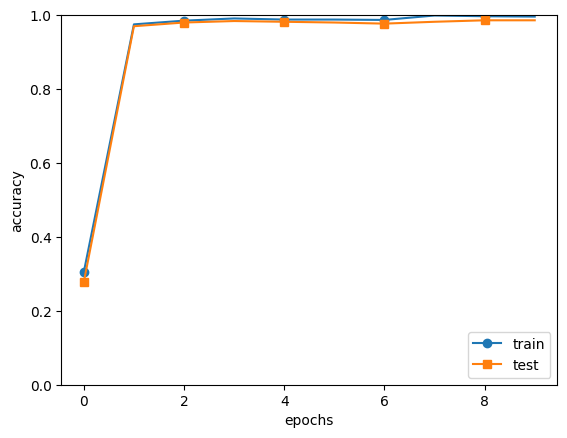

In [16]:
import matplotlib.pyplot as plt

# データの読み込み
(x_train, t_train), (x_test, t_test) = load_mnist(save_dir, flatten=False, one_hot_label=True)

# 処理に時間のかかる場合はデータを削減
#x_train, t_train = x_train[:5000], t_train[:5000]
#x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 10

network = SimpleConvNet(input_dim=(1,28,28),
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)

trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# パラメータの保存
network.save_params("params.pkl")
print("Saved Network Parameters!")

# グラフの描画
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()



## CNNの可視化

CNNの畳み込み層は何を見ているのか？ここでは畳み込み層の可視化を通じて，CNNで何が行われているのかを確認する．

先ではMNISTデータセットに対して単純なCNNの学習を行った．このとき，1層目の畳み込み層の重みの形状は (30, 1, 5, 5) であり，サイズが5✕5でチャンネルが1のフィルタが30個であった．フィルタのサイズが5✕5でチャンネル数が1ということは，フィルタを1チャンネルののグレー画像として可視化できるということを意味する．

そこで，下記のプログラムで畳み込み層 (1層目) のフィルタを画像として表示してみる．(下記のプログラムも可視化のためのプログラムなのでコピペいただいて問題ありません．興味がありましたらご確認ください)

In [18]:
def filter_show(filters, nx=8, margin=3, scale=10):
    """
    c.f. https://gist.github.com/aidiary/07d530d5e08011832b12#file-draw_weight-py
    """
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


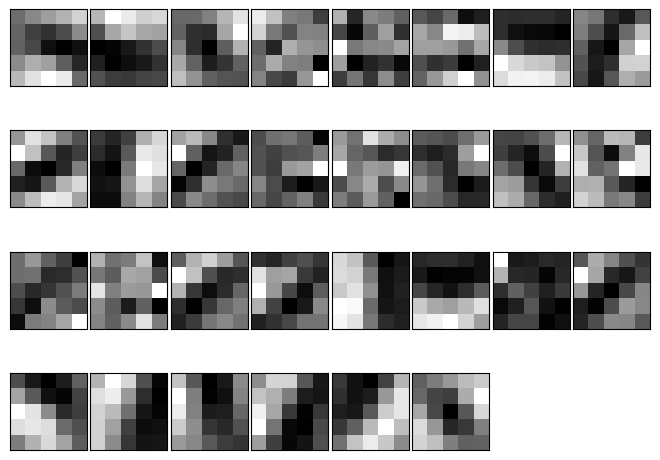

In [19]:
filter_show(network.params['W1'])

上記のように学習後のフィルタは規則性がある画像になっている．白から黒へグラデーションを伴って変化するフィルタや，塊のある領域を持ちフィルタなど，学習によって規則性のあるフィルターになっている．

一方，学習前のフィルタも確認してみる．

In [20]:
network2 = SimpleConvNet(input_dim=(1,28,28),
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)

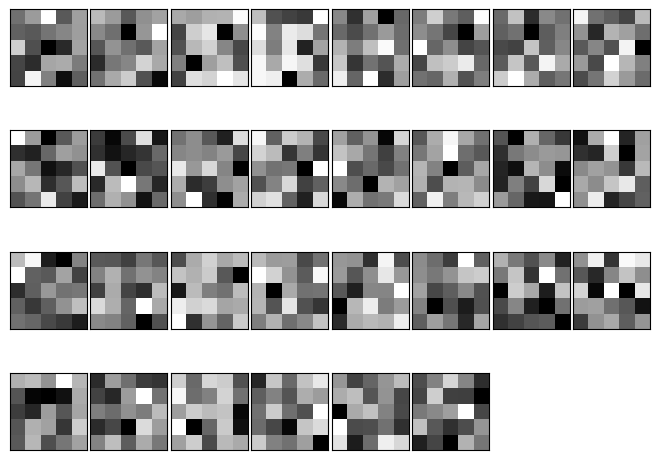

In [21]:
filter_show(network2.params['W1'])

上記のように学習前のフィルタはランダムに初期化されているため，白黒の濃淡には規則性がない．

学習によって規則性を持ったフィルタは何を見ているのか？
それは，エッジや局所的に塊のある領域などを見ている．例えば，左半分が白で右半分が黒のフィルタの場合，縦方向のエッジに反応するフィルタになる．